<a href="https://colab.research.google.com/github/Stamatics-NumberstoNeurons/assignment2-Himanshu-445/blob/main/Assignment_2_N2N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [35]:
#code here
class NANDPerceptron:
    def __init__(self):
        # Weights and bias mathematically determined for NAND logic
        # NAND gives 0 only when both inputs are 1.
        self.weights = np.array([-2, -2])
        self.bias = 3

    def predict(self, X):
        # Vectorized operation: X is shape (N, 2)
        # z = X.W + b
        z = np.dot(X, self.weights) + self.bias
        # Step function: 1 if z >= 0 else 0
        return (z >= 0).astype(int)

# Verify
nand_gate = NANDPerceptron()
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
print(f"Inputs:\n{X}")
print(f"Outputs: {nand_gate.predict(X)}")

Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Outputs: [1 1 1 0]


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:**A tiny change in one weight can cause chaos in a perceptron network because perceptrons rely on a rigid step function for their activation. A microscopic adjustment in a weight can shift the linear combination z=w.x+b from small negative to small positive (or vice versa), which violently flips the output from 0 to 1 (or 1 to 0). This sudden discontinuity makes it impossible to use gradient descent, as we cannot gauge whether small adjustments are gradually improving the network.

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:**1.As c tends to infinity, the sigmoid neuron behaves exactly like a classic perceptron. Mathematically, sigma(cz) = 1/1 + e^(-cz). If z is even slightly positive, cz tends to infinity and sigma tends to 1. If z is even slightly negative, cz tends to minus infinity and sigma tends to 0. This perfectly recreates the harsh boundary of a step function.
2.We prefer sigmoid neurons because their activation function is smooth and continuously differentiable. This allows us to calculate gradients, meaning small adjustments to weights yield proportionally small, predictable changes in output, enabling the network to learn via gradient descent.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**The factor of 1/2 is included purely for mathematical convenience during calculus. When calculating the derivative of the squared error term ||y(x) - a||^2 with respect to a weight, the exponent 2 is brought down by the power rule. It cancels out perfectly with the 1/2, leaving a clean derivative expression without a stray leading constant of 2.

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:**The Quadratic Cost formula is $C = 1/2n sigma |y(x) - a|^2.With n = 2:C = 1/4 [ (1.0 - 0.9)^2 + (0.0 - 0.3)^2 ] C = 1/4 [ (0.1)^2 + (-0.3)^2 ] C = 1/4 [ 0.01 + 0.09 ] = 1/4(0.10) = 0.025. This value (0.025) is very close to 0, which tells us the network's predictions are highly accurate and closely matching the target outputs.

In [36]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

C_val = None  # TODO: compute C
print(f'C = {C_val}')

C = None


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:**Classification accuracy is a discrete metric (a prediction is either entirely right or entirely wrong), making it a step-like function that is flat almost everywhere. We cannot compute a meaningful gradient for it. We use a smooth cost function because it is continuous and differentiable, providing a landscape where gradient descent can figure out exactly which direction and how much to adjust the weights to systematically reduce the error.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:**One major problem with using absolute error is that the function is not differentiable at exactly zero. Because its derivative jumps from -1 to 1, the gradient is discontinuous. While squared error has a smooth, continuous gradient that naturally shrinks to zero at the minimum, the discontinuous gradient of absolute error makes it mathematically problematic to optimize using standard gradient descent

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:**By inspection, the minimum occurs at w = 3 and b = 1. The cost function is the sum of two squared terms. Since squared real numbers can never be negative, the absolute minimum possible value for C is 0. This minimum is achieved only when both squared terms equal zero simultaneously, which requires w - 3 = 0 and b - 1 = 0.

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:**Partial derivatives:
dC/dw = 2(w - 3)
dC/db = 4(b - 1)

1.at (0,0).
dC/dw = 2(-3) = -6
dC/db = 4(-1) = -4
w1 = 0 - 0.1(-6) = 0.6
b1 = 0 - 0.1(-4) = 0.4

2.at (0.6, 0.4).
dC/dw = 2(0.6 - 3) = -4.8
dC/db = 4(0.4 - 1) = -2.4
w2 = 0.6 - 0.1(-4.8) = 1.08
b2 = 0.4 - 0.1(-2.4) = 0.64

After 2, the parameter vector ends up at w = 1.08, b = 0.64.

In [37]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2 * (w - 3)
    db = 4 * (b - 1)
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:**With a learning rate of 0.6, the update for b overshoots the minimum and grows larger in magnitude each step.
Start b=0, db=-4. Next b = 0 - 0.6(-4) = 2.4 (Minimum is 1, we overshot to 2.4).
Next db = 4(2.4 - 1) = 5.6. Next b = 2.4 - 0.6(5.6) = -0.96.
Next db = 4(-0.96 - 1) = -7.84. Next b = -0.96 - 0.6(-7.84) = 3.744.
The value oscillates around the minimum and diverges further away. This demonstrates that if the learning rate is set too high, the algorithm will overshoot the valley of the cost function and fail to converge.

In [38]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [39]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        # TODO: compute z = w.x + b, return sigmoid(z)
        z = np.dot(self.weights, x) + self.bias
        return 1.0 / (1.0 + np.exp(-z))

    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        # return (grad_weights, grad_bias)
        grad_weights = np.zeros_like(self.weights)

    # Gradient w.r.t weights
        for i in range(len(self.weights)):
            w_orig = self.weights[i]

            self.weights[i] = w_orig + h
            out_plus = self.forward(x)

            self.weights[i] = w_orig - h
            out_minus = self.forward(x)

            grad_weights[i] = (out_plus - out_minus) / (2 * h)
            self.weights[i] = w_orig # reset

    # Gradient w.r.t bias
        b_orig = self.bias
        self.bias = b_orig + h
        out_plus = self.forward(x)
        self.bias = b_orig - h
        out_minus = self.forward(x)
        grad_bias = (out_plus - out_minus) / (2 * h)
        self.bias = b_orig # reset

        return grad_weights, grad_bias

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [40]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:**The gradient with respect to w1 tells us the exact rate at which the neuron's final output will change if we make a tiny change to the first weight. For example, if the gradient is 0.15, it means a small increase in w1 will cause the sigmoid output to increase by 0.15 times that small amount.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**The gradient is largest at exactly z = 0, where the derivative reaches its peak value of 0.25.

As z approaches positive or negative infinity, the derivative rapidly approaches 0. This is known as the vanishing gradient . It is problematic because if a neuron's activation is saturated (very high or very low), the gradient effectively becomes zero, meaning the network stops learning since weights are no longer updated during backpropagation.

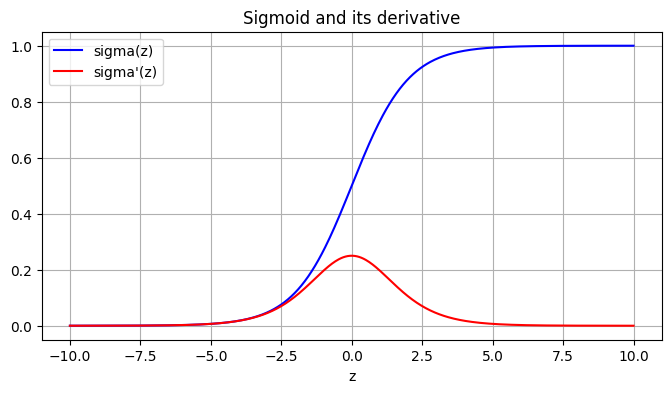

In [41]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma = 1.0 / (1.0 + np.exp(-z))
sigma_prime = sigma * (1 - sigma)

plt.figure(figsize=(8, 4))
# TODO: plot both curves
plt.plot(z, sigma, label='sigma(z)', color='blue')
plt.plot(z, sigma_prime, label="sigma'(z)", color='red')
plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:**The claim iscorrect for practical purposes. By multiplying the inputs by a massive scalar (100), the transition zone of the sigmoid function gets compressed horizontally. It transitions from 0 to 1 almost instantly around z=0, just like the boundary of a step function. It theoretically breaks down exactly at z=0 (where the sigmoid equals 0.5, whereas a perceptron is usually defined strictly as 0 or 1), but at a macro scale, it acts like a perceptron.

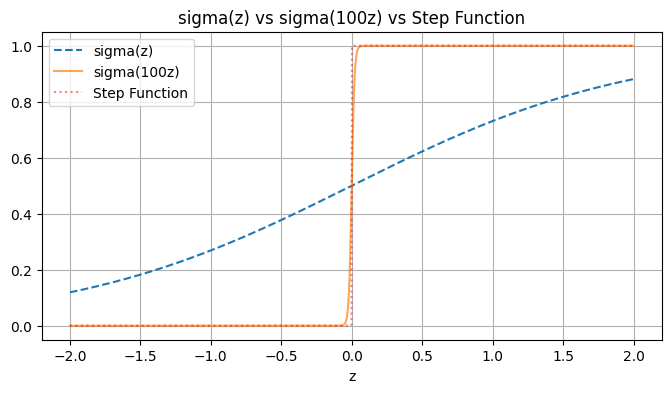

In [48]:
z = np.linspace(-2, 2, 1000)

# TODO: compute sigma(z), sigma(100*z), step function
sigma_z = 1.0 / (1.0 + np.exp(-z))
sigma_100z = 1.0 / (1.0 + np.exp(-100 * z))
step_func = (z >= 0).astype(int)
plt.figure(figsize=(8, 4))
# TODO: plot all three
plt.plot(z, sigma_z, label='sigma(z)', linestyle='--')
plt.plot(z, sigma_100z, label='sigma(100z)', alpha=0.7)
plt.plot(z, step_func, label='Step Function', color='red', alpha=0.5, linestyle=':')
plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [43]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:**C = 1/(2n) * sum( (w*x_i + b - y_i)^2 )

Using the chain rule:
dC/dw = 1/(2n) * sum( 2(wx_i + b - y_i) * x_i ) = 1/n * sum( x_i * (wx_i + b - y_i) )
dC/db = 1/(2n) * sum( 2(wx_i + b - y_i) * 1 ) = 1/n * sum( wx_i + b - y_i )

Yes, looking at the output of the full-batch gradient descent code, w and b successfully converge to approximately 3 and 1.

Final w = 2.9910, b = 1.0256


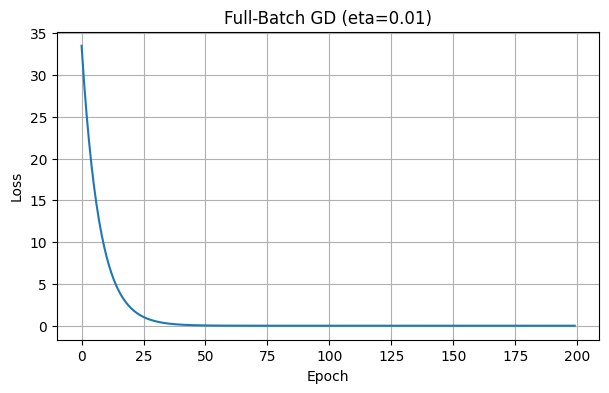

In [51]:
w, b = 0.0, 0.0
eta = 0.01
losses = []
n = len(X_train)
for epoch in range(200):
    # TODO: predictions, loss, gradients, update
    predictions = w * X_train + b
    errors = predictions - y_train

    loss = (1 / (2 * n)) * np.sum(errors**2)
    losses.append(loss)

    dw = (1 / n) * np.sum(errors * X_train)
    db = (1 / n) * np.sum(errors)

    w = w - eta * dw
    b = b - eta * db

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**The loss curve for Stochastic Gradient Descent (SGD) is visibly jagged and noisy compared to the smooth descent of Full-Batch GD. This happens because SGD calculates the gradient using only a single, randomly selected data point at a time. The direction of steepest descent for one specific point is rarely the perfect direction for the entire dataset, leading to chaotic, "noisy" steps. However, on average, the general trend still pushes the parameters toward the global minimum

Final w = 2.9978, b = 1.0062


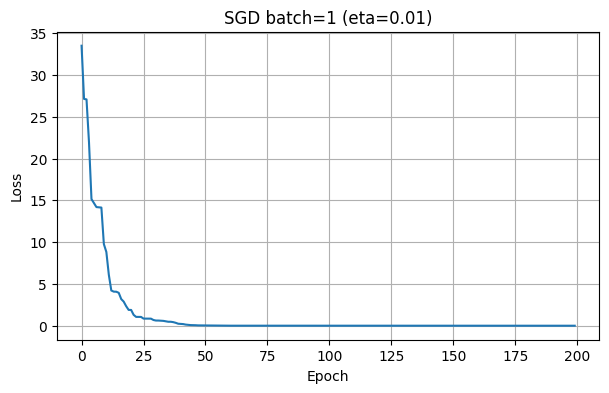

In [52]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []

for epoch in range(200):
    # TODO: pick random example, compute gradient, update
   # Picking random example
    i = np.random.randint(0, n)
    x_i = X_train[i]
    y_i = y_train[i]

    # Prediction and loss
    pred = w * x_i + b
    error = pred - y_i

    full_loss = (1 / (2 * n)) * np.sum(((w * X_train + b) - y_train)**2)
    losses_sgd.append(full_loss)

    dw = error * x_i
    db = error

    w = w - eta * dw
    b = b - eta * db

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**The learning rate 0.5 is too large for the scale of the gradients in this dataset. Looking at the formula dC/dw = 1/n * sum( x_i * (w*x_i + b - y_i) ), the gradient incorporates an x_i multiplier. Since some x values are up to 4, the gradients become relatively large. Taking a step size scaled by 0.5 results in overshooting the minimum so drastically that the error on the next step is even larger than the previous one, causing the loss to explode exponentially (divergence).

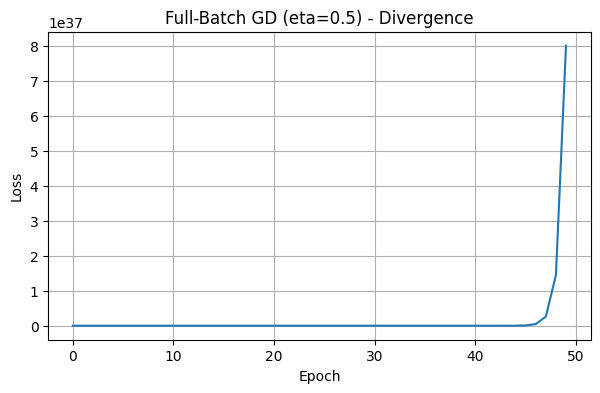

In [54]:
w, b = 0.0, 0.0
eta = 0.5 # Setting eta to 0.5
losses_div = []
n = len(X_train)
import warnings
warnings.filterwarnings('ignore')

for epoch in range(50):
   predictions = w * X_train + b
   errors = predictions - y_train

   loss = (1 / (2 * n)) * np.sum(errors**2)
   losses_div.append(loss)

   if loss is not None and not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

   dw = (1 / n) * np.sum(errors * X_train)
   db = (1 / n) * np.sum(errors)

   w = w - eta * dw
   b = b - eta * db

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:**The goal is to map a 10-dimensional one-hot vector (e.g., [0, 0, 1, 0, ..., 0] for digit 2) to a 4-dimensional binary vector (e.g., [0, 0, 1, 0]). Since the one-hot vector only has a single 1 and the rest are 0s, matrix multiplication W * x simply extracts a specific column of W. Therefore, each column of the weight matrix W should represent the exact 4-bit binary sequence for that digit. We can set the bias to 0 and use a hard threshold at 0.5

In [55]:
# TODO: define W (4x10) and b_enc (4,)
W = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1], # 8s place
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0], # 4s place
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0], # 2s place
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]  # 1s place
], dtype=float)

b_enc = np.zeros(4)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**Geometrically, dC/dv is the slope of the tangent line touching the curve at the point v. The update rule tells us to move our point v in the direction opposite to the slope. If the curve slopes upward (positive derivative), we subtract, moving left down the hill. If the curve slopes downward (negative derivative), we add, moving right down the hill.

The slope determines the direction of the movement and acts as a dynamic multiplier for the step size (steeper slopes yield larger steps to traverse down quickly; shallow slopes yield smaller steps to prevent overshooting the bottom). The learning rate (alpha) scales this overall calculation, acting physically as our stride length. A small alpha means tip-toeing, while a large alpha means taking massive jumps.

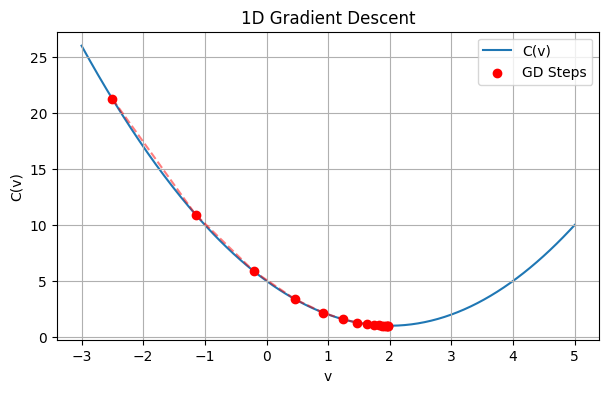

In [56]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

# TODO: run gradient descent steps and annotate on the curve
v_current = -2.5
alpha = 0.15
history_v = [v_current]
history_c = [(v_current - 2)**2 + 1]

for _ in range(15):
    # dC/dv = 2(v - 2)
    grad = 2 * (v_current - 2)
    v_current = v_current - alpha * grad

    history_v.append(v_current)
    history_c.append((v_current - 2)**2 + 1)

plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)', zorder=1)
plt.scatter(history_v, history_c, color='red', label='GD Steps', zorder=2)
plt.plot(history_v, history_c, color='red', linestyle='--', alpha=0.5, zorder=2)

plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**By connecting inputs directly to the outputs with no hidden layers, you have mathematically created a simple Linear Regression or Logistic/Softmax Regression model (depending on your final activation function).

Classification accuracy is fundamentally capped because this architecture can only learn linearly separable patterns. It attempts to draw a single straight hyper-plane to separate classes. If the data is intertwined in a non-linear way, the model simply lacks the geometric flexibility to separate them.

This implies that hidden layers are strictly necessary for extracting complex, non-linear representations from the data. The hidden layers warp, fold, and transform the input space so that complex intertwined data becomes linearly separable by the time it reaches the final output layer